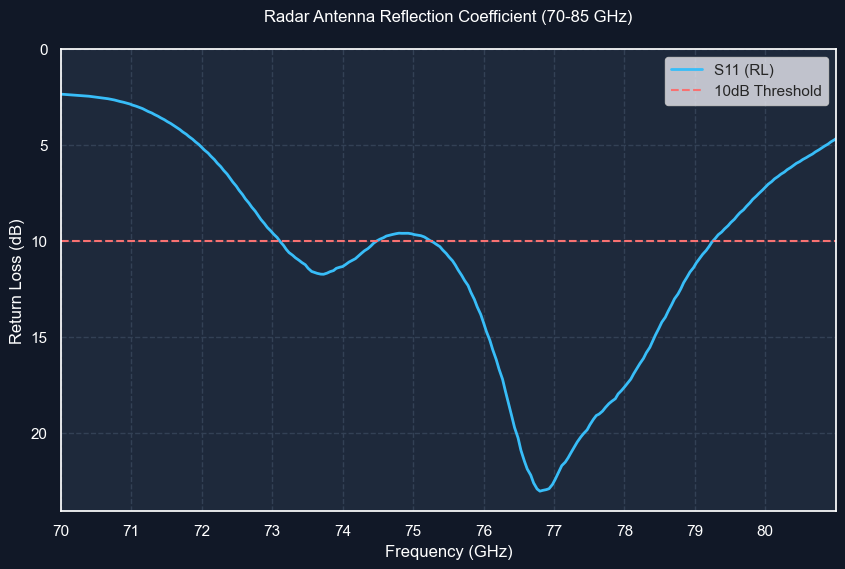

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data (skipping the header lines starting with ! or #)
df = pd.read_csv('ant_radar_reflection_coef.s1p', sep=r'\s+', skiprows=5, names=['freq', 'real', 'imag'])

# 2. Calculate Magnitude and Return Loss (dB)
df['mag'] = np.sqrt(df['real']**2 + df['imag']**2)
df['return_loss'] = 20 * np.log10(df['mag'])

# 3. Clean Frequency (rounding for the axis)
# df['freq'] = df['freq'].round(2)
df['freq'] = (df['freq'] / 1e9).round(2)
sns.set_theme(style="dark")
plt.figure(figsize=(10, 6), facecolor='#111827') # Matching your portfolio theme
ax = plt.axes()
ax.set_facecolor("#1e293b")

# Plotting the Return Loss
plt.plot(df['freq'], -df['return_loss'], color='#38bdf8', linewidth=2, label='S11 (RL)')

# Adding a threshold line for "Good Match" (usually -10dB)
plt.axhline(y=10, color='#f87171', linestyle='--', label='10dB Threshold')
plt.gca().invert_yaxis()
# Customizing the look
plt.title("Radar Antenna Reflection Coefficient (70-85 GHz)", color='white', pad=20)
plt.xlabel("Frequency (GHz)", color='white')
plt.ylabel("Return Loss (dB)", color='white')
plt.grid(color='#334155', linestyle='--')
plt.xlim(70, 81)
# Create an array of numbers from 70 to 80 with a step of 1
plt.xticks(np.arange(70, 81, 1), color = "white")
plt.yticks(np.arange(0, 25, 5), color = "white")
plt.legend()
plt.savefig('plot_RL_radarBands.png', transparent=True, dpi=300)

plt.show()

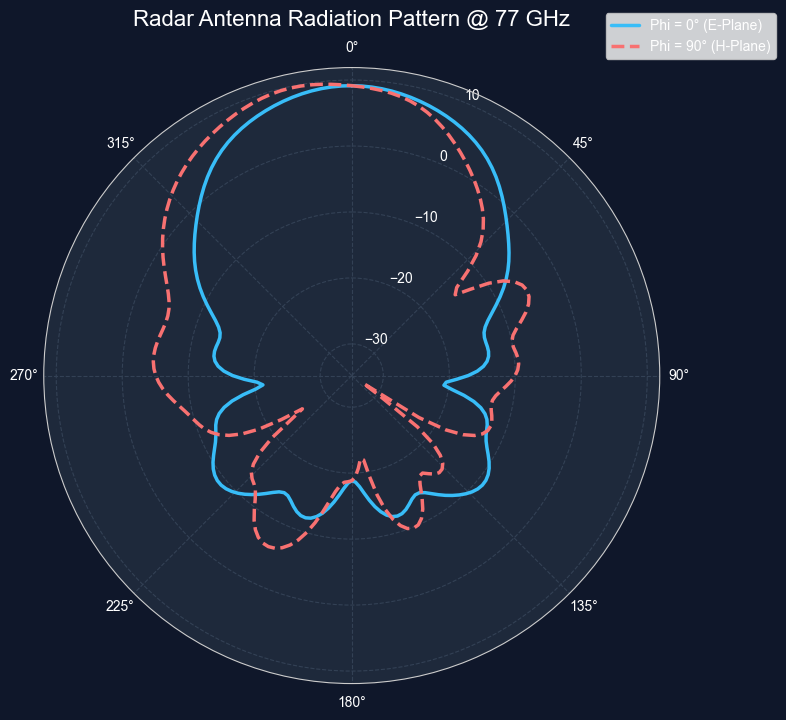

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the CSV data
df_phi0 = pd.read_csv('Realizedgain_77_phi0.csv', sep=',', skiprows=1, header=None)
df_phi90 = pd.read_csv('Realizedgain_77_phi90.csv', sep=',', skiprows=1, header=None)

# Rename columns for both to ensure consistency
cols = ['freq', 'phi', 'theta', 'gain']
df_phi0.columns = cols
df_phi90.columns = cols

# 2. Convert Theta to Radians for both datasets
df_phi0['theta_rad'] = np.radians(df_phi0['theta'])
df_phi90['theta_rad'] = np.radians(df_phi90['theta'])

# 3. Create the Polar Plot
plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='polar')

# Plot the gain patterns
ax.plot(df_phi0['theta_rad'], df_phi0['gain'],
        color='#38bdf8', linewidth=2.5, label='Phi = 0° (E-Plane)')

ax.plot(df_phi90['theta_rad'], df_phi90['gain'],
        color='#f87171', linewidth=2.5, label='Phi = 90° (H-Plane)', linestyle='--')

# 4. Styling
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title("Radar Antenna Radiation Pattern @ 77 GHz", color='white', pad=30, fontsize=16)

# Add a Legend
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.setp(legend.get_texts(), color='white')

# Dark theme adjustments
ax.set_facecolor('#1e293b')
plt.gcf().set_facecolor('#0f172a')
ax.tick_params(colors='white')
ax.grid(color='#334155', linestyle='--')
plt.savefig('2D_realGain_77GHz.png', transparent=True, dpi=300)
plt.show()

In [26]:
df_phi0.head()
print(df_phi0.head())

   freq  phi  theta      gain  theta_rad
0    77    0      0  9.146056   0.000000
1    77    0      2  9.114937   0.034907
2    77    0      4  9.036986   0.069813
3    77    0      6  8.914594   0.104720
4    77    0      8  8.750755   0.139626
